# Head-Fixed — Confidence-Threshold Analysis

Copy of `plot_head_fixed_updated.ipynb` with a confidence-analysis section:
error/coverage vs threshold, risk-coverage curves (the fair recipe comparison),
and per-keypoint error at a chosen threshold. Configure runs in Option C, then
run the confidence cells. The original ensemble-std section is kept at the end.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr
import seaborn as sns

## Utility functions

The ensemble/statistics algorithm is unchanged from the reference notebook. The two
storage-related extensions remain:
- `compute_ensemble_stddev` accepts an optional `keypoints` list.
- `build_ensemble` accepts an `error_csv_dict`, because each run now keeps evaluation
  artifacts under `eval/<dataset>/predictions.csv` and `eval/<dataset>/pixel_error.csv`.

In [2]:
def standardize_scorer_level(df, new_scorer='standard_scorer'):
    df.columns = pd.MultiIndex.from_tuples(
        [(new_scorer, bodypart, coord) for _, bodypart, coord in df.columns],
        names=df.columns.names,
    )
    return df


def compute_ensemble_stddev(df_preds, scorer_name='standard_scorer', keypoints=None):
    """Compute per-frame, per-keypoint ensemble std dev across models.
    
    keypoints: optional list of bodypart names to include (filters by name).
        Used to restrict mixed-model predictions to the eval dataset's keypoints.
    """
    preds = []
    for i, df in enumerate(df_preds):
        df = standardize_scorer_level(df, scorer_name)

        cols_to_keep = [
            col for col in df.columns
            if not col[2].endswith('likelihood') and 'Unnamed' not in col[2]
        ]
        if keypoints is not None:
            # ordered selection so the stddev column order matches the keypoints list
            cols_to_keep = [
                col for kp in keypoints for col in cols_to_keep if col[1] == kp
            ]
        df = df[cols_to_keep]

        if df.isna().any().any():
            nan_indices = df[df.isna().any(axis=1)].index
            nan_columns = df.columns[df.isna().any()]
            print(f'Warning: NaN values in DataFrame {i} — indices: {nan_indices}, columns: {nan_columns}')

        arr_np = df.to_numpy()
        try:
            arr = arr_np.reshape(df.shape[0], -1, 2)
        except ValueError as e:
            print(f'Reshape error: {e}  shape={arr_np.shape}')
            raise
        preds.append(arr)

    preds = np.stack(preds, axis=-1)  # (n_frames, n_keypoints, 2, n_models)

    if np.isnan(preds).any():
        print(f'Warning: NaN values in stacked preds array')
    else:
        print('No NaN values in preds array.')

    return np.std(preds, axis=-1).mean(axis=-1)  # (n_frames, n_keypoints)


def compute_percentiles(arr, std_vals, percentiles):
    num_pts = arr[0]
    vals, prctiles = [], []
    for p in percentiles:
        idx = np.argmin(np.abs(arr - num_pts * p / 100))
        achieved = arr[idx] / num_pts * 100 if idx == len(arr) - 1 else p
        vals.append(std_vals[idx])
        prctiles.append(np.round(achieved, 2))
    return vals, prctiles


class Ensemble:
    data_to_plot: dict[str, str]  # model label -> path to predictions CSV
    pred_csv_list: list[str]
    error_csv_list: list[str]
    df_pred_list: list[pd.DataFrame]
    df_error_list: list[pd.DataFrame]
    n_points_dict: dict[str, dict[str, int]]
    std_vals: list[float]
    df_w_vars: pd.DataFrame
    df_line2: pd.DataFrame


def build_ensemble(ens, std_val_max=8.0, error_csv_dict=None, keypoints=None):
    """Load predictions and pixel errors, compute ensemble statistics.
    
    error_csv_dict: optional dict mapping each key in ens.data_to_plot to an
        explicit pixel-error CSV path. If None, derives path from pred CSV stem
        (original behaviour: predictions_test.csv -> predictions_pixel_error_test.csv).
    keypoints: optional list of bodypart names passed to compute_ensemble_stddev.
    """
    model_names_list = list(ens.data_to_plot.keys())
    pred_csv_list = [Path(v) for v in ens.data_to_plot.values()]

    if error_csv_dict is not None:
        error_csv_list = [Path(error_csv_dict[k]) for k in model_names_list]
    else:
        error_csv_list = [
            p.with_stem(
                p.stem
                .replace('_new', '_pixel_error_new')
                .replace('_test', '_pixel_error_test')
            )
            for p in pred_csv_list
        ]

    df_pred_list, df_error_list = [], []
    for pred_csv, error_csv in zip(pred_csv_list, error_csv_list):
        df_pred_list.append(pd.read_csv(pred_csv, header=[0, 1, 2], index_col=0).sort_index())
        df = pd.read_csv(error_csv, header=[0], index_col=0).sort_index()
        if 'set' in df.columns:
            df = df.drop(columns=['set'])
        if keypoints is not None:
            # keep error columns in the same order as the keypoints list, so the
            # enumerate() below indexes the stddev array consistently
            df = df[[k for k in keypoints if k in df.columns]]
        df_error_list.append(df)

    ens_stddev = compute_ensemble_stddev(df_pred_list, keypoints=keypoints)

    df_w_vars = []
    for df_error, df_pred, model_name in zip(df_error_list, df_pred_list, model_names_list):
        assert (df_error.index == df_pred_list[0].index).all()
        assert (df_pred.index == df_pred_list[0].index).all()

        print(f'Total pixel error for model {model_name}: {df_error.sum().sum()}')

        for i, kp in enumerate(df_error.columns):
            index = [f'{frame}_{model_name}_{kp}' for frame in df_error.index]
            df_pred_std = standardize_scorer_level(df_pred.copy())
            df_w_vars.append(pd.DataFrame(
                {
                    'pixel_error': df_error[kp].values,
                    'likelihood': df_pred_std.loc[:, ('standard_scorer', kp, 'likelihood')].values,
                    'ens-std': ens_stddev[:, i],
                    'ens-std-prctile': [
                        np.sum(ens_stddev < p) / ens_stddev.size for p in ens_stddev[:, i]
                    ],
                    'ens-std-prctile-kp': [
                        np.sum(ens_stddev[:, i] < p) / ens_stddev[:, i].size for p in ens_stddev[:, i]
                    ],
                    'keypoint': kp,
                    'model': model_name,
                },
                index=index,
            ))

    df_w_vars = pd.concat(df_w_vars)
    std_vals = np.arange(0, std_val_max, 0.25)
    n_points_dict = {m: np.nan * np.zeros_like(std_vals) for m in model_names_list}

    df_line2 = []
    for s, std in enumerate(std_vals):
        df_tmp_ = df_w_vars[df_w_vars['ens-std'] > std]
        for model_name in model_names_list:
            d = df_tmp_[df_tmp_.model == model_name]
            n_points_dict[model_name][s] = np.sum(~d['pixel_error'].isna())
            df_line2.append(pd.DataFrame(
                {
                    'ens-std': std,
                    'model': model_name,
                    'pixel_error': d.pixel_error.to_numpy(),
                    'keypoint': d['keypoint'].to_numpy(),
                },
                index=[f'{row}_{s}' for row in d.index],
            ))

    ens.pred_csv_list = pred_csv_list
    ens.error_csv_list = error_csv_list
    ens.df_pred_list = df_pred_list
    ens.df_error_list = df_error_list
    ens.n_points_dict = n_points_dict
    ens.std_vals = std_vals
    ens.df_w_vars = df_w_vars
    ens.df_line2 = pd.concat(df_line2)
    return ens

## Configuration

Choose one option below. Every trained model is evaluated on all four held-out datasets,
so the evaluation target is independent of the training tag. Valid targets are `facemap`,
`ibl`, `cheese-2d`, and `cazettes-side`.

### Option A — compare training tags (single backbone)

Compares n=1, n−1, and n=all training tags for one fixed `backbone`. Every
condition uses `tf1` (all frames in its CSV).

Head mode and sampling temperature are orthogonal to the tag — the same extra
path components `make_output_dir` writes (`head-per_dataset`, `sampling-T2`,
…). Adding an n−1 tag is: put its CSV stem in `condition_catalog`, add the
label to `conditions_to_plot`. Variants that exist on disk are loaded;
missing ones (n=1 is stock-only today) are skipped.

Run **this cell** (and skip Option B below), then continue to "Main plot".

In [3]:
# from itertools import product

# from mouse_pose.train import head_mode_tag, temperature_tag

# # ── paths ──────────────────────────────────────────────────────────────────────
# RESULTS_ROOT = Path('/teamspace/studios/this_studio/poseinterface/results')
# result_set   = 'head-fixed'  # working run, or a frozen directory such as head-fixed_vN
# RESULTS_DIR  = RESULTS_ROOT / result_set

# # ── eval target ────────────────────────────────────────────────────────────────
# eval_dataset = 'ibl'  # 'facemap' | 'ibl' | 'cheese-2d' | 'cazettes-side' | 'kondo'
# eval_subdir  = 'eval'  # 'eval' | 'eval_blind'

# # ── sweep parameters ───────────────────────────────────────────────────────────
# backbone     = 'vits_dinov3'
# losses       = 'supervised'
# train_frames = 1
# # seeds      = [0, 1, 2]
# seeds        = [0]

# # Same conventions as mouse_pose.train.make_output_dir: None / 'shared' and
# # None / 1 omit the path component, so stock runs stay at
# # <stem>/supervised/tf1/<backbone>/seedN. Crossed with every selected tag;
# # combos that are not on disk are skipped (n=1 is stock-only today).
# head_modes   = [None, 'per_dataset']
# temperatures = [None, 2, 'inf']

# # ── training tags ──────────────────────────────────────────────────────────────
# # Directory names are the train CSV stem after 'CollectedData_'. A new n−1
# # tag is one catalog entry plus its label in conditions_to_plot.
# condition_catalog = {
#     # n=1
#     'facemap':       'facemap_train',
#     'ibl':           'ibl_train',
#     'cheese-2d':     'cheese-2d_train',
#     'cazettes-side': 'cazettes-side_train',
#     'kondo':         'kondo_train',
#     # n-1
#     'ibl+cheese-2d+cazettes-side':     'ibl+cheese-2d+cazettes-side_train',
#     'facemap+cheese-2d+cazettes-side': 'facemap+cheese-2d+cazettes-side_train',
#     'facemap+ibl+cazettes-side':       'facemap+ibl+cazettes-side_train',
#     'facemap+ibl+cheese-2d':           'facemap+ibl+cheese-2d_train',
#     # n=all
#     'face+ibl+cheese+caz+kondo': 'face+ibl+cheese+caz+kondo_train',
# }

# # Select completed training tags. Expand this as the sweep finishes.
# conditions_to_plot = [
#     # 'facemap',
#     'ibl',
#     # 'cheese-2d',
#     # 'cazettes-side',
#     # 'kondo',
#     # n-1
#     # 'ibl+cheese-2d+cazettes-side',
#     # 'facemap+cheese-2d+cazettes-side',
#     # 'facemap+ibl+cazettes-side',
#     # 'facemap+ibl+cheese-2d',
#     # n=all
#     'face+ibl+cheese+caz+kondo',
# ]

# ylim_map = {
#     'facemap':       80,
#     'ibl':           40,
#     'cheese-2d':     100,
#     'cazettes-side': 80,
#     'kondo':         100,
# }

# # ── resolve stored evaluation files ────────────────────────────────────────────
# def _sanitize(s):
#     return s.replace('/', '_').replace('.', '_')


# def _series_label(condition, head_mode, temperature):
#     parts = [condition]
#     if head_mode_tag(head_mode) is not None:
#         parts.append(head_mode.replace('_', '-'))
#     if temperature_tag(temperature) is not None:
#         parts.append(f'T{temperature}')
#     return ' '.join(parts)


# def _eval_paths(csv_stem, backbone, seed, head_mode=None, temperature=None):
#     parts = [csv_stem, losses]
#     if (tag := head_mode_tag(head_mode)) is not None:
#         parts.append(tag)
#     if (tag := temperature_tag(temperature)) is not None:
#         parts.append(tag)
#     parts += [f'tf{train_frames}', _sanitize(backbone), f'seed{seed}']
#     eval_dir = RESULTS_DIR.joinpath(*parts) / eval_subdir / eval_dataset
#     return eval_dir / 'predictions.csv', eval_dir / 'pixel_error.csv'


# ens = Ensemble()
# ens.data_to_plot = {}
# error_csv_dict   = {}
# models_to_plot   = []
# skipped          = []

# for label in conditions_to_plot:
#     n_found_for_tag = 0
#     looked_for      = []
#     for head_mode, temperature in product(head_modes, temperatures):
#         series = _series_label(label, head_mode, temperature)
#         n_found_for_series = 0
#         for seed in seeds:
#             pred_csv, error_csv = _eval_paths(
#                 condition_catalog[label], backbone, seed,
#                 head_mode=head_mode, temperature=temperature,
#             )
#             looked_for.extend([pred_csv, error_csv])
#             if pred_csv.is_file() and error_csv.is_file():
#                 key = f'{series}.{seed}'
#                 ens.data_to_plot[key] = str(pred_csv)
#                 error_csv_dict[key]   = str(error_csv)
#                 n_found_for_series += 1
#             else:
#                 skipped.append(series)
#         if n_found_for_series:
#             models_to_plot.append(series)
#             n_found_for_tag += n_found_for_series
#     if n_found_for_tag == 0:
#         raise FileNotFoundError(
#             f'No evaluation files for {label!r} under '
#             f'{RESULTS_DIR / condition_catalog[label]}\n'
#             + '\n'.join(str(p) for p in looked_for)
#         )

# print('Loaded series:')
# for series in models_to_plot:
#     n = sum(1 for k in ens.data_to_plot if k.startswith(series + '.'))
#     print(f'  {series}  ({n} seed(s))')
# if skipped:
#     unique_skipped = list(dict.fromkeys(skipped))
#     print(f'Skipped {len(unique_skipped)} missing variant(s): {unique_skipped}')

# build_ensemble(ens, error_csv_dict=error_csv_dict)

# colors         = sns.color_palette('tab10', n_colors=len(models_to_plot))
# color_mapping  = dict(zip(models_to_plot, colors))
# dataset_name   = eval_dataset


# def major_model(s):
#     return '.'.join(s.split('.')[:-1])


# ens.df_line2['model2'] = ens.df_line2['model'].apply(major_model)

### Option B — compare backbones (single training tag)

Compares multiple backbones for one current training condition. It resolves the same
`<result_set>/<csv_stem>/supervised/tf1/<backbone>/seedN/eval/<dataset>/` layout and
populates the same plotting variables as Option A.

Run **this cell** (and skip Option A above), then continue to "Main plot".

In [4]:
# # ── paths ──────────────────────────────────────────────────────────────────────
# RESULTS_ROOT = Path('/teamspace/studios/this_studio/poseinterface/results')
# result_set   = 'head-fixed'  # working run, or a frozen directory such as head-fixed_vN
# RESULTS_DIR  = RESULTS_ROOT / result_set

# # ── eval target ────────────────────────────────────────────────────────────────
# eval_dataset = 'ibl'  # 'facemap' | 'ibl' | 'cheese-2d' | 'cazettes-side'

# # ── fixed model condition ──────────────────────────────────────────────────────
# csv_stem     = 'ibl_train'  # directory stem after 'CollectedData_'
# train_frames = 1            # all frames in the CSV
# losses       = 'supervised'
# seeds        = [0, 1, 2]

# # ── backbones to compare ───────────────────────────────────────────────────────
# # Add a backbone after all requested seeds have evaluation files.
# backbones = [
#     'vits_dinov3',
#     # 'vits_dino', 'vits_dinov2', 'vitb_dinov3',
# ]

# ylim_map = {
#     'facemap':       80,
#     'ibl':           40,
#     'cheese-2d':     100,
#     'cazettes-side': 80,
#     'kondo':         80,
# }
# colors = sns.color_palette('tab10', n_colors=len(backbones))

# # ── resolve stored evaluation files ────────────────────────────────────────────
# def _sanitize(s):
#     return s.replace('/', '_').replace('.', '_')


# def _eval_paths(backbone, seed):
#     run_dir = (
#         RESULTS_DIR / csv_stem / losses / f'tf{train_frames}'
#         / _sanitize(backbone) / f'seed{seed}'
#     )
#     eval_dir = run_dir / 'eval' / eval_dataset
#     return eval_dir / 'predictions.csv', eval_dir / 'pixel_error.csv'


# ens = Ensemble()
# ens.data_to_plot = {}
# error_csv_dict   = {}

# for backbone in backbones:
#     for seed in seeds:
#         key = f'{backbone}.{seed}'
#         pred_csv, error_csv = _eval_paths(backbone, seed)
#         ens.data_to_plot[key] = str(pred_csv)
#         error_csv_dict[key]   = str(error_csv)

# missing = [
#     path for path in [*ens.data_to_plot.values(), *error_csv_dict.values()]
#     if not Path(path).is_file()
# ]
# if missing:
#     raise FileNotFoundError('Missing evaluation files:\n' + '\n'.join(missing))

# build_ensemble(ens, error_csv_dict=error_csv_dict)

# models_to_plot = backbones
# color_mapping  = dict(zip(models_to_plot, colors))
# dataset_name   = eval_dataset


# def major_model(s):
#     return '.'.join(s.split('.')[:-1])


# ens.df_line2['model2'] = ens.df_line2['model'].apply(major_model)

### Option C — explicit run directories (path-based, recommended)

Compare **any** runs by pointing at their seed folders directly — sweep layouts,
`zoom-aug-exp/`, `finetune-exp/`, `scale-exp/`, anything with
`<run>/eval/<dataset>/{predictions,pixel_error}.csv`. No layout conventions needed;
mixing layouts in one plot is fine (that is the point).

- Keys are the series labels shown in the plots; values are run dirs (str or Path).
- A value may contain a glob (`.../sampling-T2/tf1/vits_dinov3/seed*`) — each match
  becomes one seed of that series.
- `keypoints_to_plot=None` uses every keypoint the eval dataset labels;
  `supported_keypoints(...)` restricts to the zero-shot supported set
  (per `docs/operations.md`).

Run **this cell** instead of Option A/B, then continue to the Main plot.

In [31]:
import glob
import json as _json

# ── paths ──────────────────────────────────────────────────────────────────────
RESULTS_ROOT = Path('/teamspace/studios/this_studio/poseinterface/results')
RESULTS_DIR  = RESULTS_ROOT / 'head-fixed'
DATA_DIR     = Path('/teamspace/studios/this_studio/poseinterface/data/head-fixed')

# ── eval target ────────────────────────────────────────────────────────────────
eval_dataset = 'cazettes-side'   # 'facemap' | 'ibl' | 'cheese-2d' | 'cazettes-side' | 'kondo'
eval_subdir  = 'eval'  # 'eval' | 'eval_blind'

# ── runs: label -> seed dir (globs allowed; each match = one seed) ─────────────
runs_to_plot = {
    # 'leave-ibl T2 (dlc aug)':
    #     RESULTS_DIR / 'face+cheese+caz+kondo_train/supervised/sampling-T2/tf1/vits_dinov3/seed0',
    # 'leave-ibl T2 zoomaug':
    #     RESULTS_DIR / 'zoom-aug-exp/face+cheese+caz+kondo-T2-zoomaug/seed0',
    
    # 'leave-facemap T2 (dlc aug)':
    #     RESULTS_DIR / 'ibl+cheese+caz+kondo_train/supervised/sampling-T2/tf1/vits_dinov3/seed0',
    # 'leave-facemap T2 zoomaug':
    #     RESULTS_DIR / 'zoom-aug-exp/ibl+cheese+caz+kondo-T2-zoomaug/seed0',
    
    # 'leave-cheese-2d T2 (dlc aug)':
    #     RESULTS_DIR / 'face+ibl+caz+kondo_train/supervised/sampling-T2/tf1/vits_dinov3/seed0',
    # 'leave-cheese-2d T2 zoomaug':
    #     RESULTS_DIR / 'zoom-aug-exp/face+ibl+caz+kondo-T2-zoomaug/seed0',
    
    # 'leave-kondo T2 (dlc aug)':
    #     RESULTS_DIR / 'face+ibl+cheese+caz_train/supervised/sampling-T2/tf1/vits_dinov3/seed0',
    # 'leave-kondo T2 zoomaug':
    #     RESULTS_DIR / 'zoom-aug-exp/face+ibl+cheese+caz-T2-zoomaug/seed0',
    
    'leave-cazettes-side T2 (dlc aug)':
        RESULTS_DIR / 'face+ibl+cheese+kondo_train/supervised/sampling-T2/tf1/vits_dinov3/seed0',
    'leave-cazettes-side T2 zoomaug':
        RESULTS_DIR / 'zoom-aug-exp/face+ibl+cheese+kondo-T2-zoomaug/seed0',
    
    # 'leave-facemap T2 (dlc aug)':
    #     RESULTS_DIR / 'ibl+cheese+caz+kondo_train/supervised/sampling-T2/tf1/vits_dinov3/seed0',
    # 'leave-facemap T2 zoomaug':
    #     RESULTS_DIR / 'zoom-aug-exp/ibl+cheese+caz+kondo-T2-zoomaug/seed0',
    
    # 'ibl':
    #     RESULTS_DIR / 'ibl_train/supervised/tf1/vits_dinov3/seed0',
    # 'facemap':
    #     RESULTS_DIR / 'facemap_train/supervised/tf1/vits_dinov3/seed0',
    # 'cheese-2d':
    #     RESULTS_DIR / 'cheese-2d_train/supervised/tf1/vits_dinov3/seed0',
    # 'kondo':
    #     RESULTS_DIR / 'kondo_train/supervised/tf1/vits_dinov3/seed0',
    'cazettes-side':
        RESULTS_DIR / 'cazettes-side_train/supervised/tf1/vits_dinov3/seed0',
    
    
    
    'All datasets T2':
        RESULTS_DIR / 'face+ibl+cheese+caz+kondo_train/supervised/sampling-T2/tf1/vits_dinov3/seed0',
    'All datasets T2 (zoomaug)':
        RESULTS_DIR / 'zoom-aug-exp/face+ibl+cheese+caz+kondo-T2-zoomaug/seed0',
    # 'All datasets T2 (token)':
    #     RESULTS_DIR / 'token-exp/face+ibl+cheese+caz+kondo-T2-token/seed0',

      
}


def supported_keypoints(target, train_datasets):
    """Zero-shot supported set: target's eval kps taught by >=1 training dataset."""
    inv = _json.load(open(DATA_DIR / 'dataset_inventory.json'))['datasets']
    teach = set().union(*[set(inv[d]['trainable']) for d in train_datasets])
    return sorted((set(inv[target]['eval']) - {'pupil_center_right'}) & teach)


keypoints_to_plot = None  # None = all keypoints the eval dataset labels
keypoints_to_plot = supported_keypoints(
    # 'ibl', ['facemap', 'cheese-2d', 'cazettes-side', 'kondo'])
    # 'facemap', ['ibl', 'cheese-2d', 'cazettes-side', 'kondo'])
    # 'cheese-2d', ['ibl', 'kondo', 'cazettes-side', 'facemap'])
    # 'kondo', ['ibl', 'cheese-2d', 'cazettes-side', 'facemap'])
    'cazettes-side', ['facemap', 'cheese-2d', 'ibl', 'kondo'])

ylim_map = {
    'facemap':       80,
    # 'ibl':           40,
    'ibl':           60,
    'cheese-2d':     100,
    'cazettes-side': 80,
    'kondo':         140,
}

# ── resolve eval files ─────────────────────────────────────────────────────────
ens = Ensemble()
ens.data_to_plot = {}
error_csv_dict   = {}
models_to_plot   = []

for label, run in runs_to_plot.items():
    run = str(run)
    matches = sorted(glob.glob(run)) if any(ch in run for ch in '*?[') else [run]
    if not matches:
        raise FileNotFoundError(f'{label!r}: no run dirs match {run}')
    for i, m in enumerate(matches):
        eval_dir  = Path(m) / eval_subdir / eval_dataset
        pred_csv  = eval_dir / 'predictions.csv'
        error_csv = eval_dir / 'pixel_error.csv'
        if not (pred_csv.is_file() and error_csv.is_file()):
            raise FileNotFoundError(f'{label!r}: missing {pred_csv} or {error_csv}')
        key = f'{label}.{i}'
        ens.data_to_plot[key] = str(pred_csv)
        error_csv_dict[key]   = str(error_csv)
    models_to_plot.append(label)
    print(f'{label}: {len(matches)} run(s)')

# I tried to add
# keypoints_to_plot = supported_keypoints(
#     'ibl', ['facemap', 'cheese-2d', 'cazettes-side', 'kondo'])
    # 'cazettes-side', ['facemap', 'cheese-2d', 'ibl', 'kondo'])
# -> ['nose_tip', 'pupil_center_left', 'wrist_left', 'wrist_right']


# default keypoint list: whatever the eval dataset's pixel_error actually scores
# (keeps the stddev array aligned with the error columns; predictions carry all 36)
if keypoints_to_plot is None:
    _err0 = pd.read_csv(next(iter(error_csv_dict.values())), nrows=0, index_col=0)
    keypoints_to_plot = [
        c for c in _err0.columns if c not in ('set', 'pupil_center_right')
    ]  # pupil_center_right is hflip-only, excluded by convention
print(f'keypoints ({len(keypoints_to_plot)}): {keypoints_to_plot}')

build_ensemble(ens, error_csv_dict=error_csv_dict, keypoints=keypoints_to_plot)

colors        = sns.color_palette('tab10', n_colors=len(models_to_plot))
color_mapping = dict(zip(models_to_plot, colors))
dataset_name  = eval_dataset


def major_model(s):
    return '.'.join(s.split('.')[:-1])


ens.df_line2['model2'] = ens.df_line2['model'].apply(major_model)

leave-cazettes-side T2 (dlc aug): 1 run(s)
leave-cazettes-side T2 zoomaug: 1 run(s)
cazettes-side: 1 run(s)
All datasets T2: 1 run(s)
All datasets T2 (zoomaug): 1 run(s)
keypoints (7): ['lowerlip', 'nose_bottom', 'nose_tip', 'pupil_center_left', 'tongue_tip', 'wrist_left', 'wrist_right']
No NaN values in preds array.
Total pixel error for model leave-cazettes-side T2 (dlc aug).0: 40178.378034615715
Total pixel error for model leave-cazettes-side T2 zoomaug.0: 39104.25365126567
Total pixel error for model cazettes-side.0: 13576.596353798948
Total pixel error for model All datasets T2.0: 12954.39971161437
Total pixel error for model All datasets T2 (zoomaug).0: 14359.65286843527


## Confidence-threshold analysis

Three views of the same question — *how good are the predictions you would actually
keep?* All read `ens.df_w_vars` (already loaded by the config cell above; every row is
one prediction with its `pixel_error` and `likelihood`), pool seeds within a series,
and share the series colors.

1. **Error and coverage vs confidence threshold** — sweep the cutoff; left panel is the
   mean error of kept predictions, right panel how many survive.
2. **Risk–coverage curve** — the threshold-free version: sort by confidence, plot mean
   error of the most-confident x% for every x. **This is the fair way to compare
   models/recipes** (a fixed threshold confounds accuracy with calibration — see
   `docs/operations.md`).
3. **Per-keypoint error at one chosen threshold** (`CONF_THRESH`) — where the kept
   error lives.

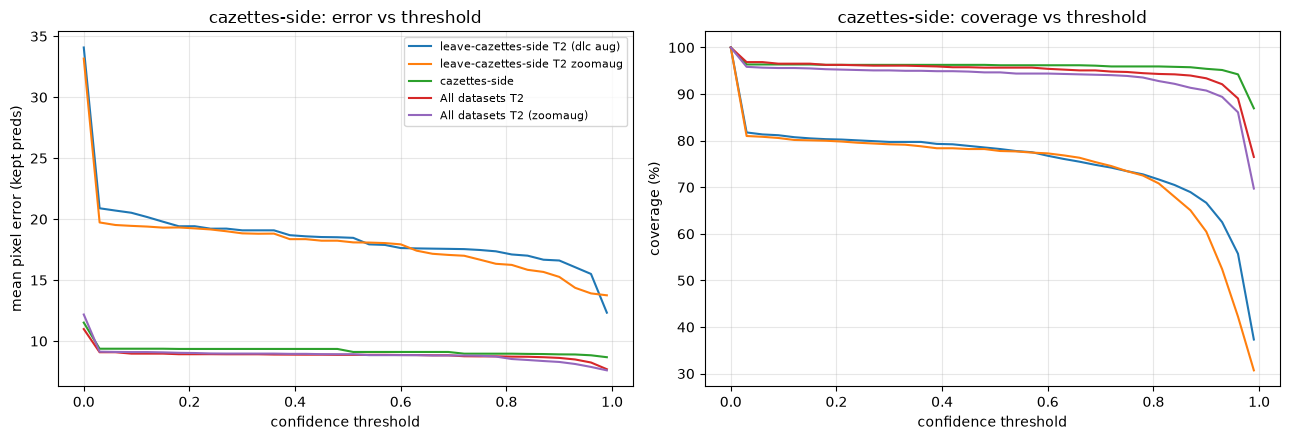

In [32]:
# ── 1. error and coverage vs confidence threshold ─────────────────────────────
dfw = ens.df_w_vars.copy()
dfw['model2'] = dfw['model'].apply(major_model)

thresholds = np.linspace(0.0, 0.99, 34)
fig, (ax_err, ax_cov) = plt.subplots(1, 2, figsize=(13, 4.5))
for series in models_to_plot:
    d = dfw[dfw['model2'] == series].dropna(subset=['pixel_error'])
    errs = [d.loc[d['likelihood'] >= t, 'pixel_error'].mean() for t in thresholds]
    covs = [(d['likelihood'] >= t).mean() * 100 for t in thresholds]
    ax_err.plot(thresholds, errs, label=series, color=color_mapping[series])
    ax_cov.plot(thresholds, covs, label=series, color=color_mapping[series])
ax_err.set(xlabel='confidence threshold', ylabel='mean pixel error (kept preds)',
           title=f'{dataset_name}: error vs threshold')
ax_cov.set(xlabel='confidence threshold', ylabel='coverage (%)',
           title=f'{dataset_name}: coverage vs threshold')
ax_err.legend(fontsize=8)
for ax in (ax_err, ax_cov):
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

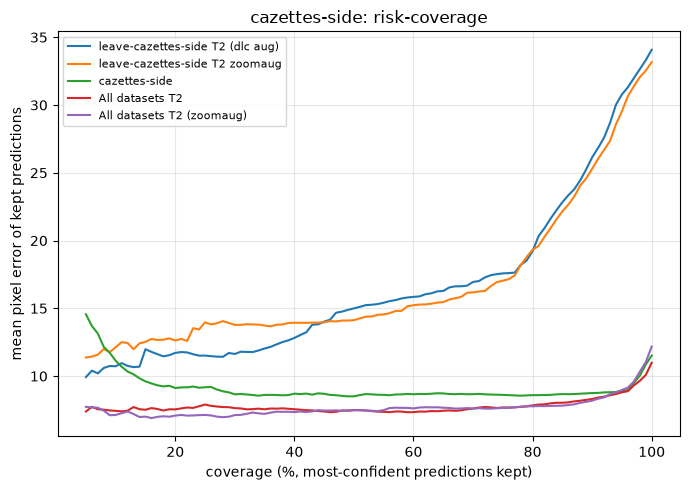

cov 70%: leave-cazettes-side T2 (dlc aug)  16.95   leave-cazettes-side T2 zoomaug  16.18   cazettes-side   8.67   All datasets T2   7.61   All datasets T2 (zoomaug)   7.60   
cov 90%: leave-cazettes-side T2 (dlc aug)  26.14   leave-cazettes-side T2 zoomaug  25.30   cazettes-side   8.75   All datasets T2   8.31   All datasets T2 (zoomaug)   8.19   
cov100%: leave-cazettes-side T2 (dlc aug)  34.08   leave-cazettes-side T2 zoomaug  33.17   cazettes-side  11.52   All datasets T2  10.99   All datasets T2 (zoomaug)  12.18   


In [33]:
# ── 2. risk-coverage curve (threshold-free; the fair model comparison) ─────────
fig, ax = plt.subplots(figsize=(7, 5))
cov_grid = np.linspace(0.05, 1.0, 96)
for series in models_to_plot:
    d = dfw[dfw['model2'] == series].dropna(subset=['pixel_error'])
    errs_sorted = d.sort_values('likelihood', ascending=False)['pixel_error'].to_numpy()
    n = len(errs_sorted)
    curve = [errs_sorted[:max(1, int(n * c))].mean() for c in cov_grid]
    ax.plot(cov_grid * 100, curve, label=series, color=color_mapping[series])
ax.set(xlabel='coverage (%, most-confident predictions kept)',
       ylabel='mean pixel error of kept predictions',
       title=f'{dataset_name}: risk-coverage')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# matched-coverage table at a few operating points
for c in [0.7, 0.9, 1.0]:
    row = f'cov{int(c * 100):3d}%: '
    for series in models_to_plot:
        d = dfw[dfw['model2'] == series].dropna(subset=['pixel_error'])
        e = d.sort_values('likelihood', ascending=False)['pixel_error'].to_numpy()
        row += f'{series} {e[:max(1, int(len(e) * c))].mean():6.2f}   '
    print(row)

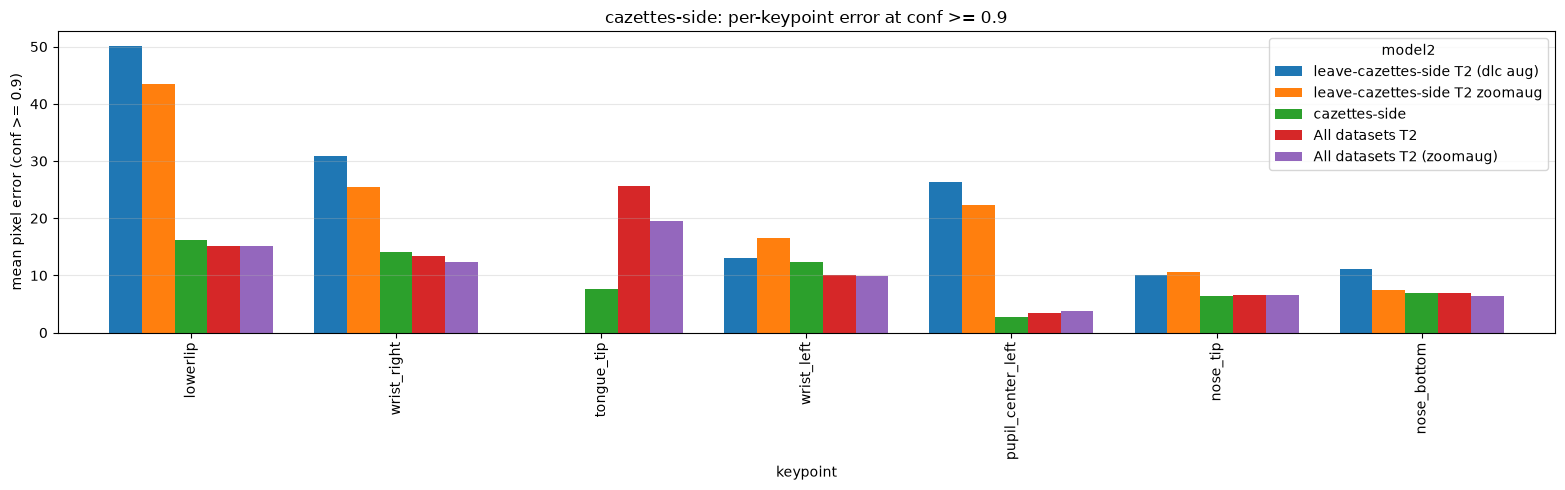

per-keypoint coverage at conf >= 0.9:
model2             leave-cazettes-side T2 (dlc aug)  leave-cazettes-side T2 zoomaug  cazettes-side  All datasets T2  All datasets T2 (zoomaug)
keypoint                                                                                                                                      
lowerlip                                          9                              13             98               94                         86
wrist_right                                      38                              16             44               57                         49
tongue_tip                                        0                               0            100               22                          8
wrist_left                                       96                              93             97              100                         97
pupil_center_left                                85                              62            100      

In [34]:
# ── 3. per-keypoint error at one threshold ─────────────────────────────────────
CONF_THRESH = 0.9

kept = dfw[dfw['likelihood'] >= CONF_THRESH].dropna(subset=['pixel_error'])
per_kp = (kept.groupby(['model2', 'keypoint'])['pixel_error'].mean()
          .unstack('model2').loc[:, models_to_plot])
per_cov = (dfw.dropna(subset=['pixel_error'])
           .assign(kept=lambda d: d['likelihood'] >= CONF_THRESH)
           .groupby(['model2', 'keypoint'])['kept'].mean()
           .unstack('model2').loc[:, models_to_plot])

order = per_kp.mean(axis=1).sort_values(ascending=False).index
ax = per_kp.loc[order].plot.bar(
    figsize=(max(8, 0.45 * len(order) * len(models_to_plot)), 5),
    color=[color_mapping[m] for m in models_to_plot], width=0.8)
ax.set(ylabel=f'mean pixel error (conf >= {CONF_THRESH})',
       title=f'{dataset_name}: per-keypoint error at conf >= {CONF_THRESH}')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'per-keypoint coverage at conf >= {CONF_THRESH}:')
print((per_cov.loc[order] * 100).round(0).astype(int).to_string())

### 4. Intersection set — identical points under filtering (strictest)

Mean error over only the (frame, keypoint) cells where **every** compared series is
above `CONF_THRESH` — the mean is over literally the same predictions for all models,
so no model benefits from abstaining. The printed size shows how much of the universe
survives; it shrinks as you add models or raise the threshold.

intersection: 659 of 1179 labeled cells (55.9%) at conf >= 0.9

mean pixel error on the IDENTICAL intersection set:
  leave-cazettes-side T2 (dlc aug)      14.49  (n=659)
  leave-cazettes-side T2 zoomaug        14.51  (n=659)
  cazettes-side                          7.67  (n=659)
  All datasets T2                        7.09  (n=659)
  All datasets T2 (zoomaug)              7.06  (n=659)


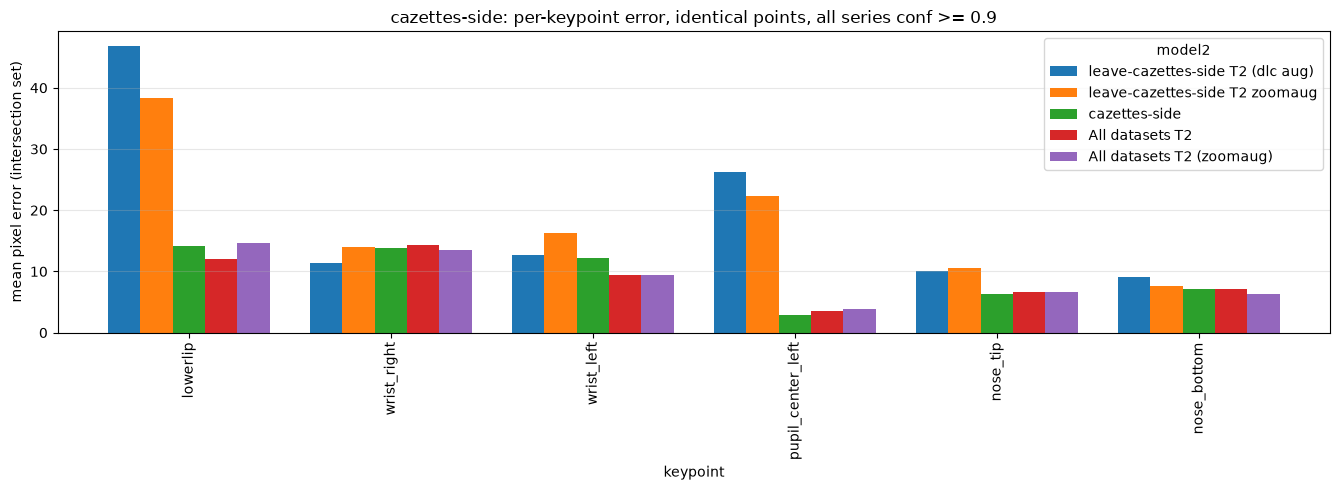

In [35]:
# ── 4. intersection set: every series confident on the same (frame, keypoint) ──
# rows of df_w_vars are indexed by f'{frame}_{model_key}_{keypoint}'; rebuild a
# (frame, keypoint) cell id per row so cells can be matched across series
dfx = dfw.dropna(subset=['pixel_error']).copy()
n_strip = dfx['model'].str.len() + dfx['keypoint'].str.len() + 2
dfx['frame'] = [idx[:len(idx) - k] for idx, k in zip(dfx.index, n_strip)]
dfx['cell'] = dfx['frame'] + '||' + dfx['keypoint']

confident = dfx[dfx['likelihood'] >= CONF_THRESH]
# a cell is in the intersection when every series is confident there (pool seeds:
# require the series' mean-over-seeds min likelihood >= threshold via per-series any/all)
per_series_cells = {
    s: set(confident.loc[confident['model2'] == s, 'cell'])
    for s in models_to_plot
}
inter = set.intersection(*per_series_cells.values())
universe = dfx.groupby('cell').size()
print(f'intersection: {len(inter)} of {dfx["cell"].nunique()} labeled cells '
      f'({100 * len(inter) / dfx["cell"].nunique():.1f}%) at conf >= {CONF_THRESH}')

sub = dfx[dfx['cell'].isin(inter)]
print(f'\nmean pixel error on the IDENTICAL intersection set:')
for s in models_to_plot:
    d = sub[sub['model2'] == s]
    print(f'  {s:35s} {d["pixel_error"].mean():7.2f}  (n={len(d)})')

per_kp_inter = (sub.groupby(['model2', 'keypoint'])['pixel_error'].mean()
                .unstack('model2').reindex(columns=models_to_plot))
order_i = per_kp_inter.mean(axis=1).sort_values(ascending=False).index
ax = per_kp_inter.loc[order_i].plot.bar(
    figsize=(max(8, 0.45 * len(order_i) * len(models_to_plot)), 5),
    color=[color_mapping[m] for m in models_to_plot], width=0.8)
ax.set(ylabel='mean pixel error (intersection set)',
       title=f'{dataset_name}: per-keypoint error, identical points, '
             f'all series conf >= {CONF_THRESH}')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Main plot

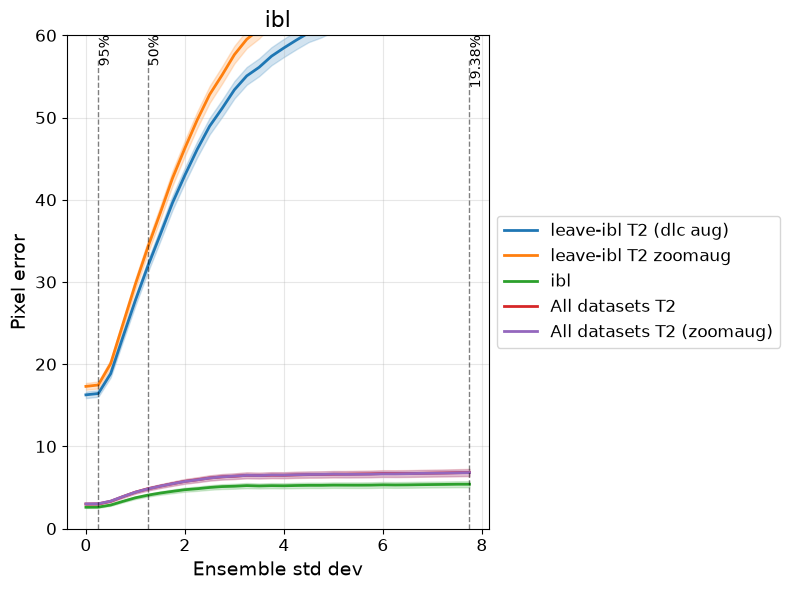

In [9]:
df_line2      = ens.df_line2
n_points_dict = ens.n_points_dict
std_vals      = ens.std_vals

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for model in models_to_plot:
    data = df_line2[df_line2['model2'] == model].reset_index(drop=True)
    sns.lineplot(x='ens-std', y='pixel_error', data=data, label=model,
                 color=color_mapping[model], ax=ax, errorbar='se', linewidth=2)

ax.set_title(f'{dataset_name}', fontsize=16)
ax.set_ylabel('Pixel error', fontsize=14)
ax.set_xlabel('Ensemble std dev', fontsize=14)
ax.set_ylim(bottom=0)
if dataset_name in ylim_map:
    ax.set_ylim(top=ylim_map[dataset_name])
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

# percentile annotations based on first model's first seed
percentiles = [95, 50, 5]
vals, prctiles = compute_percentiles(
    arr=n_points_dict[f'{models_to_plot[0]}.0'],
    std_vals=std_vals,
    percentiles=percentiles,
)
for p, v in zip(prctiles, vals):
    ax.axvline(v, ymax=0.95, linestyle='--', linewidth=1, color='black', alpha=0.5)
    ax.text(v, ax.get_ylim()[1], f'{p}%', ha='left', va='top', fontsize=10, rotation=90)

plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [82]:
# Calculate column widths
model_width = max(len(model) for model in models_to_plot)
val_width = 8  # Adjust based on your data precision needs

# Print header
print('|' + ' ' * model_width + '|', end='')
for val in prctiles:
    print(f'{val:^{val_width}}|', end='')
print()

# Print separator line
print('|' + '-' * model_width + '|', end='')
for val in prctiles:
    print('-' * val_width + '|', end='')
print()

# Print data rows
for model in models_to_plot:
    print(f'|{model:<{model_width}}|', end='')
    for val in vals:
        err = df_line2[(df_line2['ens-std']==val) & (df_line2['model2']==model)].pixel_error.mean()
        print(f'{round(err, 2):^{val_width}}|', end='')
    print()

# Print bottom border
print('|' + '-' * model_width + '|', end='')
for val in vals:
    print('-' * val_width + '|', end='')
print()

|                                |   95   |   50   | 31.72  |
|--------------------------------|--------|--------|--------|
|leave-cazettes-side T2 (dlc aug)| 35.67  | 56.54  | 75.38  |
|leave-cazettes-side T2 zoomaug  | 34.69  | 54.72  | 73.64  |
|cazettes-side                   | 11.83  | 14.62  | 18.75  |
|--------------------------------|--------|--------|--------|


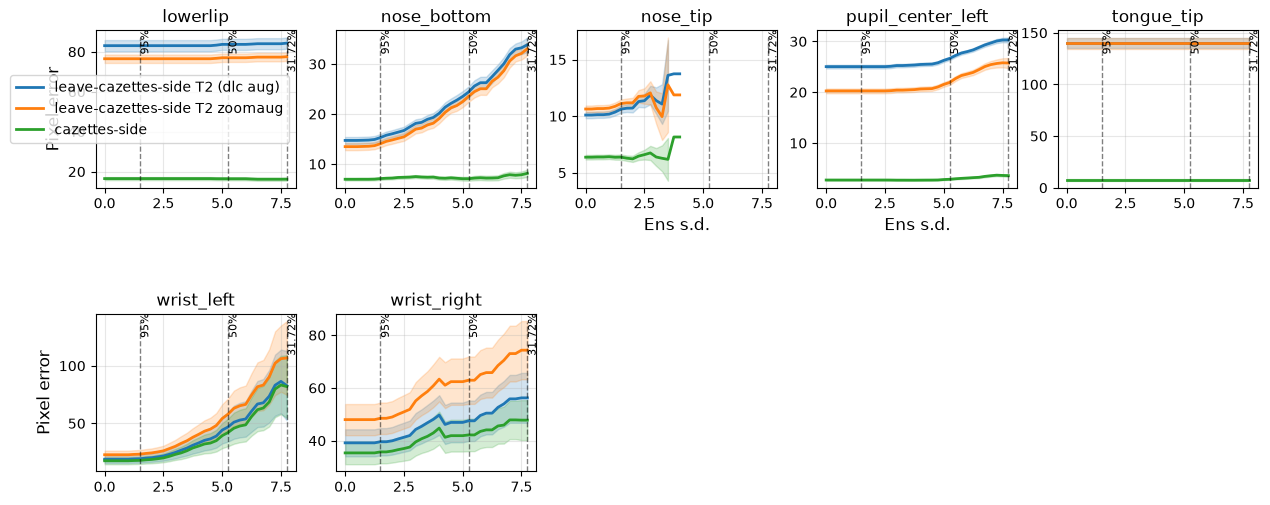

In [83]:
keypoints = ens.df_error_list[0].columns.tolist()
ncols = 5
nrows = int(np.ceil(len(keypoints) / 4))
fig, axes = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(3 * ncols, 3.5 * nrows),
)
axes = axes.flatten()
for ax in axes:
    ax.axis('off')

#models_to_plot = list(ens.data_to_plot.keys())
df_line2 = ens.df_line2
n_points_dict = ens.n_points_dict
std_vals = ens.std_vals

for j, keypoint in enumerate(keypoints):
    ax = axes[j]
    ax.axis('on')
    for model in models_to_plot:
        data = df_line2[
            (df_line2["model2"] == model) & (df_line2["keypoint"] == keypoint)
        ].reset_index(drop=True)
        sns.lineplot(
            x="ens-std",
            y="pixel_error",
            data=data,
            label=model,
            color=color_mapping[model],
            ax=ax,
            errorbar="se",
            linewidth=2,
        )

    if j % ncols == 0:
        ax.set_ylabel(f"Pixel error", fontsize=12)
    else:
        ax.set_ylabel('')
    if (j // nrows) == nrows - 1:
        ax.set_xlabel('Ens s.d.', fontsize=12)
    else:
        ax.set_xlabel('')
    ax.set_title(keypoint, fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=10)

    # Display legend only for right hand side plot.
    if j != 0:
        ax.legend().set_visible(False)
        # ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8, frameon=False)

    # Plot annotations
    percentiles = [95, 50, 5]
    vals, prctiles = compute_percentiles(
        arr=n_points_dict[models_to_plot[0] + '.0'],
        std_vals=std_vals,
        percentiles=percentiles,
    )

    for p, v in zip(prctiles, vals):
        ax.axvline(
            v, ymax=0.95, linestyle="--", linewidth=1, color="black", alpha=0.5
        )
        ax.text(
            v,
            ax.get_ylim()[1],
            f"{p}%",
            ha="left",
            va="top",
            fontsize=8,
            rotation=90,
        )

    ax.grid(True, alpha=0.3)

plt.subplots_adjust(bottom=0.25, hspace=0.8)
plt.show()